# Lab 05: RNNs vs. Transformers vs. Vision Transformers
## ITAI 2376 — Deep Learning | Spring 2026
### Houston City College — AI & Robotics Program

---

**Welcome to Lab 05!** This is a comprehensive, hands-on lab where you will build, train, and compare three major deep learning architectures:

| Part | Architecture | Task | Dataset |
|------|-------------|------|---------|
| **A** | LSTM & GRU (RNNs) | News Topic Classification | AG News |
| **B** | DistilBERT (Transformer) | News Topic Classification | AG News (same data!) |
| **C** | Vision Transformer (ViT) | Image Classification | CIFAR-10 |
| **D** | — | Comparative Analysis & Reflection | All results |

**Why this lab matters:** By using the *same text dataset* for both RNNs and Transformers, you get a direct, apples-to-apples comparison. Then, by exploring Vision Transformers, you see how the Transformer idea extends beyond text into images — and you can compare ViT performance to the CNNs you built in Module 03.

**Estimated Time:** 3–4 hours  
**Environment:** Google Colab (free tier is sufficient)

---

⚠️ **Important:** Run cells in order. If you restart the runtime, re-run all cells from the top.

---
## Part 0: Environment Setup

First, let's install libraries and check GPU access. GPU is not strictly required but makes training much faster.

**If no GPU:** Runtime → Change runtime type → T4 GPU. If unavailable, reduce epochs or dataset size as noted in the troubleshooting section at the end.

In [2]:
# Cell 0.1 — Install Required Libraries
# This cell installs the external libraries needed for this lab:
#   - transformers: Hugging Face library for pre-trained models (BERT, ViT)
#   - datasets: Hugging Face library for loading standard datasets (AG News, CIFAR-10)
#   - accelerate: Helps optimize training on different hardware (GPU/CPU)
# The -q flag makes installation quiet (less verbose output)

!pip install transformers datasets accelerate -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [1]:
# Cell 0.2 — Import Core Libraries and Check GPU Availability

# ========== DEEP LEARNING FRAMEWORK ==========
import torch                          # PyTorch: main deep learning framework
import torch.nn as nn                 # Neural network modules (layers, loss functions)
import torch.optim as optim           # Optimization algorithms (Adam, SGD, etc.)
from torch.utils.data import DataLoader, Dataset  # Data loading utilities for batching

# ========== DATA PROCESSING ==========
import numpy as np                    # Numerical operations on arrays
from collections import Counter       # Count word frequencies for vocabulary building
import re                             # Regular expressions for text cleaning

# ========== VISUALIZATION ==========
import matplotlib.pyplot as plt       # Plotting library for charts and graphs

# ========== UTILITIES ==========
import time                           # Track training time per epoch
import warnings                       # Suppress non-critical warnings
warnings.filterwarnings('ignore')     # Hide deprecation and other warnings for cleaner output

# ========== HUGGING FACE LIBRARIES (imported later when needed) ==========
# from datasets import load_dataset   # For loading AG News dataset
# from transformers import ...        # For DistilBERT and ViT models
# from torchvision import ...         # For CIFAR-10 dataset and image transforms

# ========== DEVICE CONFIGURATION ==========
# Check if CUDA-enabled GPU is available; otherwise use CPU
# Training on GPU is 10-50x faster than CPU for deep learning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

if device.type == 'cuda':
    # Display GPU name (e.g., Tesla T4, A100)
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  No GPU detected. Training will be slower. See troubleshooting tips at end.")

🖥️  Device: cuda
   GPU: Tesla T4


---
# Part A: RNN Text Classification (LSTM & GRU)

In Module 04, you learned about Recurrent Neural Networks — architectures that process sequences step by step, maintaining a hidden state that acts as "memory." Now you put that knowledge into practice.

**Your task:** Build LSTM and GRU classifiers to categorize news articles into four topics:
- 🌍 **World** — international news
- 🏈 **Sports** — athletic events
- 💼 **Business** — financial and corporate news
- 🔬 **Sci/Tech** — science and technology

We use the **AG News** dataset — a well-known benchmark. We use a subset to keep training fast on free Colab.

### Step A.1 — Load and Explore AG News

In [3]:
# Cell A.1 — Load AG News Dataset
# Import the Hugging Face datasets library for easy access to standard datasets
from datasets import load_dataset

# Load the AG News dataset (4-class news topic classification)
# This dataset contains news articles labeled as: World, Sports, Business, Sci/Tech
dataset = load_dataset("ag_news")

# Define subset sizes to keep training time reasonable on free Colab
TRAIN_SIZE = 8000  # 2000 samples per class (4 classes × 2000 = 8000)
TEST_SIZE  = 2000  # 500 samples per class (4 classes × 500 = 2000)

# Shuffle and select subsets (seed=42 ensures reproducibility)
train_data = dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_data  = dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))

# Define human-readable class names (labels are 0, 1, 2, 3)
CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

# Display dataset information
print(f"Training samples: {len(train_data)}")
print(f"Test samples:     {len(test_data)}")
print(f"\n--- Sample article ---")
print(f"Label: {CLASS_NAMES[train_data[0]['label']]}")
print(f"Text:  {train_data[0]['text'][:300]}...")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Training samples: 8000
Test samples:     2000

--- Sample article ---
Label: World
Text:  Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally....


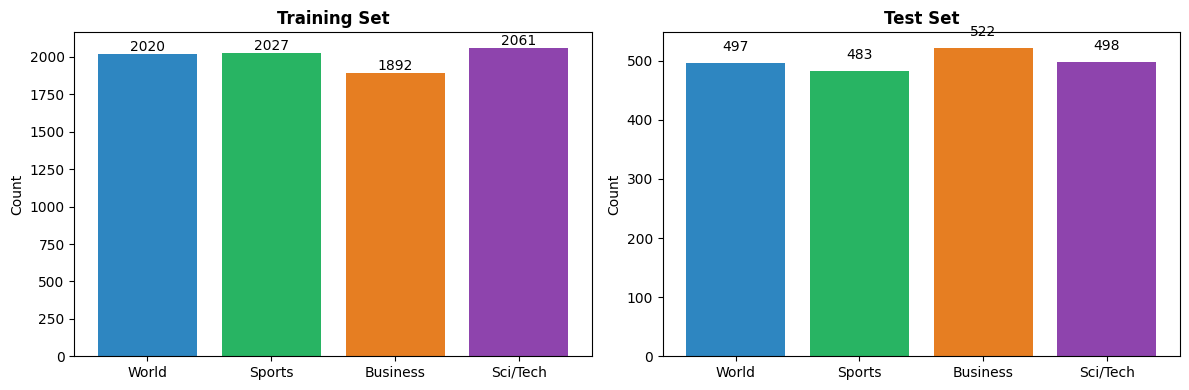

In [4]:
# Cell A.2 — Visualize Class Distribution
# It's important to check if classes are balanced (equal representation)
# Imbalanced datasets can bias the model toward majority classes

# Extract labels from training and test sets
train_labels = [s['label'] for s in train_data]
test_labels = [s['label'] for s in test_data]

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, title in zip(axes, [train_labels, test_labels], ['Training Set', 'Test Set']):
    # Count occurrences of each class
    counts = Counter(labels)
    # Create bar chart with distinct colors for each class
    bars = ax.bar(CLASS_NAMES, [counts[i] for i in range(4)],
                   color=['#2E86C1','#28B463','#E67E22','#8E44AD'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    # Add count labels on top of each bar
    for bar, c in zip(bars, [counts[i] for i in range(4)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(c), ha='center')

plt.tight_layout()
plt.show()

### Step A.2 — Text Preprocessing

Neural networks cannot process raw text. We need to:
1. **Tokenize** — split text into words
2. **Build a vocabulary** — assign a unique number to each word
3. **Convert to sequences** — replace words with numbers
4. **Pad sequences** — make all sequences the same length for batching

This is the same pipeline from Module 04, implemented from scratch.

In [5]:
# Cell A.3 — Build Vocabulary and Preprocess Text

def tokenize(text):
    """
    Convert text to lowercase and split into words.

    Steps:
    1. Convert to lowercase ("Hello" and "hello" should be the same word)
    2. Remove punctuation and special characters (keep only letters, numbers, spaces)
    3. Split on whitespace to get individual words

    Example: "Hello, World!" → ["hello", "world"]
    """
    text = text.lower()                      # Convert to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation
    return text.split()                      # Split into words

# Count word frequencies across all training documents
# This helps us identify the most common words to include in our vocabulary
word_counts = Counter()
for sample in train_data:
    word_counts.update(tokenize(sample['text']))

# ========== VOCABULARY PARAMETERS ==========
VOCAB_SIZE = 10000  # Keep only the 10,000 most common words
MAX_LEN = 128       # Truncate/pad all sequences to 128 tokens
PAD_IDX = 0         # Index for padding token (fills shorter sequences)
UNK_IDX = 1         # Index for unknown words (not in vocabulary)

# Select the top (VOCAB_SIZE - 2) most common words
# We reserve indices 0 and 1 for <PAD> and <UNK>
most_common = word_counts.most_common(VOCAB_SIZE - 2)

# Create word-to-index mapping (dictionary)
# Each word gets a unique integer ID starting from 2
word2idx = {word: idx+2 for idx, (word, _) in enumerate(most_common)}
word2idx['<PAD>'] = PAD_IDX  # Special token for padding
word2idx['<UNK>'] = UNK_IDX  # Special token for unknown words

print(f"Vocabulary size: {len(word2idx):,}")
print(f"Max sequence length: {MAX_LEN}")
print(f"Top 10 words: {[w for w, _ in most_common[:10]]}")

Vocabulary size: 10,000
Max sequence length: 128
Top 10 words: ['the', 'to', 'a', 'of', 'in', 'and', 'on', 'for', '39s', 'that']


In [6]:
# Cell A.4 — Create PyTorch Dataset
# PyTorch requires data in a specific format for efficient batching and loading

class NewsDataset(Dataset):
    """
    Custom PyTorch Dataset for AG News.

    Converts raw text into:
    - Padded sequences of word indices (input for the model)
    - Integer labels (target for classification)
    """
    def __init__(self, data, word2idx, max_len):
        self.texts, self.labels = [], []

        for sample in data:
            # Step 1: Tokenize text and convert words to indices
            # If a word is not in vocabulary, use UNK_IDX
            indices = [word2idx.get(w, UNK_IDX) for w in tokenize(sample['text'])[:max_len]]

            # Step 2: Pad sequence to max_len (add PAD_IDX to the end)
            # This ensures all sequences have the same length for batching
            indices += [PAD_IDX] * (max_len - len(indices))

            # Step 3: Convert to PyTorch tensor
            self.texts.append(torch.tensor(indices, dtype=torch.long))
            self.labels.append(sample['label'])

        # Convert labels to tensor
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.labels)

    def __getitem__(self, idx):
        """Return a single sample (text, label) at the given index."""
        return self.texts[idx], self.labels[idx]

# ========== CREATE DATASETS AND DATA LOADERS ==========
BATCH_SIZE = 64  # Process 64 samples at a time (adjust based on GPU memory)

# Create dataset objects
train_dataset = NewsDataset(train_data, word2idx, MAX_LEN)
test_dataset  = NewsDataset(test_data, word2idx, MAX_LEN)

# Create data loaders (handle batching and shuffling)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Display sample information
sample_text, sample_label = train_dataset[0]
print(f"Text tensor shape: {sample_text.shape}")
print(f"Label: {sample_label.item()} ({CLASS_NAMES[sample_label.item()]})")
print(f"Training batches: {len(train_loader)}")

Text tensor shape: torch.Size([128])
Label: 0 (World)
Training batches: 125


### Step A.3 — Build the LSTM Model

Architecture:
1. **Embedding layer** — converts word indices into dense vectors
2. **Bidirectional LSTM** — reads the sequence in both directions
3. **Fully connected layer** — maps LSTM output to 4 class predictions

In [7]:
# Cell A.5 — LSTM Classifier

class LSTMClassifier(nn.Module):
    """
    LSTM-based text classifier.

    Architecture:
    1. Embedding: Converts word indices to dense vectors (e.g., 5234 → [0.2, -0.5, ...])
    2. Bidirectional LSTM: Processes sequence forward and backward to capture context
    3. Dropout: Prevents overfitting by randomly dropping connections during training
    4. Fully Connected: Maps LSTM output to class probabilities
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer: vocab_size × embed_dim matrix
        # Each word index is mapped to a dense vector of size embed_dim
        # padding_idx=PAD_IDX ensures padding tokens don't contribute to learning
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Bidirectional LSTM layer
        # - embed_dim: size of input vectors (from embedding)
        # - hidden_dim: size of hidden state (LSTM memory)
        # - batch_first=True: input shape is (batch, sequence, features)
        # - bidirectional=True: process sequence left-to-right AND right-to-left
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout layer: randomly sets 30% of activations to zero during training
        # This prevents the model from relying too heavily on specific features
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer: maps LSTM output to class scores
        # hidden_dim * 2 because bidirectional LSTM concatenates forward and backward outputs
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of word indices, shape (batch_size, max_len)

        Returns:
            Class scores, shape (batch_size, num_classes)
        """
        # Step 1: Convert word indices to embeddings
        # Shape: (batch_size, max_len) → (batch_size, max_len, embed_dim)
        embedded = self.embedding(x)

        # Step 2: Pass through LSTM
        # output: all hidden states, shape (batch_size, max_len, hidden_dim * 2)
        # hidden: final hidden states, shape (2, batch_size, hidden_dim)
        #         [0] = forward direction, [1] = backward direction
        # cell: final cell states (not used for classification)
        output, (hidden, cell) = self.lstm(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        # hidden[-2] = last forward hidden state
        # hidden[-1] = last backward hidden state
        # Result shape: (batch_size, hidden_dim * 2)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        # Output shape: (batch_size, num_classes)
        return self.fc(self.dropout(hidden))

# ========== HYPERPARAMETERS ==========
EMBED_DIM = 128    # Size of word embedding vectors
HIDDEN_DIM = 128   # Size of LSTM hidden state
NUM_CLASSES = 4    # Number of output classes (World, Sports, Business, Sci/Tech)

# Create model and move to GPU (if available)
lstm_model = LSTMClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Count total trainable parameters
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM Parameters: 1,545,220


### 📝 Knowledge Check A.1

1. **Why do we use `bidirectional=True`?** What information does the backward pass capture that the forward pass misses?
2. **What is the purpose of the Embedding layer?** How is it different from one-hot encoding?
3. **Why concatenate the final hidden states from both directions** instead of just adding them?

**Your answers:**

1. When reading text forward, the model only sees what came before a word. But meaning often depends on what comes after too. For example, in "I went to the bank to fish" the word "fish" at the end tells you "bank" means a river bank, not a financial institution. The backward pass reads the sentence right-to-left and captures that future context. Using both directions gives the model the full picture.

2. One-hot encoding represents each word as a giant vector of zeros with a single 1, treating every word as completely unrelated to every other word. The Embedding layer instead maps each word to a small dense vector where similar words end up close together. For example "king" and "queen" end up near each other in embedding space. It is more compact and actually captures meaning.

3. When you add two vectors together, information gets mixed and you cannot tell which part came from which direction. Concatenating keeps them separate so the fully connected layer can see both the forward and backward context independently. It also doubles the information passed to the classifier (128 + 128 = 256 features instead of 128).

### Step A.4 — Build the GRU Model

GRUs have **two gates** (reset, update) vs. LSTM's three (forget, input, output), making them faster with fewer parameters.

**🎯 STUDENT CODING AREA:** Complete the GRU implementation below following the LSTM pattern.

In [8]:
# Cell A.6 — GRU Classifier

class GRUClassifier(nn.Module):
    """
    GRU-based text classifier.
    Similar to LSTM but with a simpler gating mechanism:
    - Reset gate: decides how much past information to forget
    - Update gate: decides how much new information to add
    No separate cell state (unlike LSTM), making it computationally faster.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer (same as LSTM)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # GRU layer: simpler than LSTM, only 2 gates instead of 3
        # bidirectional=True: reads sequence in both directions
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout and fully connected layers (same as LSTM)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the GRU network.
        Key difference from LSTM: GRU returns (output, hidden) — no cell state.
        """
        # Step 1: Convert word indices to embeddings
        embedded = self.embedding(x)

        # Step 2: Pass through GRU — returns (output, hidden), no cell state
        output, hidden = self.gru(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        return self.fc(self.dropout(hidden))

# Create GRU model
gru_model = GRUClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

print(f"GRU Parameters:  {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"Difference: {sum(p.numel() for p in lstm_model.parameters()) - sum(p.numel() for p in gru_model.parameters()):,} fewer in GRU")

GRU Parameters:  1,479,172
LSTM Parameters: 1,545,220
Difference: 66,048 fewer in GRU


### 🎯 Student Coding Exercise A.7 — Build a Vanilla RNN Classifier

Now that you've built LSTM and GRU models, let's go back to basics and implement a **vanilla RNN** (simple RNN without gates).

**Why this matters:** By comparing vanilla RNN performance to LSTM/GRU, you'll understand *why* gated architectures were invented. Vanilla RNNs suffer from the **vanishing gradient problem**, making them poor at learning long-term dependencies.

**Your task:**
1. Create a `VanillaRNNClassifier` class similar to LSTM/GRU
2. Use `nn.RNN` instead of `nn.LSTM` or `nn.GRU`
3. Train it for 3 epochs
4. Compare accuracy to LSTM and GRU

**Hints:**
- `nn.RNN` has the same API as `nn.LSTM` and `nn.GRU`
- It returns `(output, hidden)` like GRU (no cell state)
- Everything else (embedding, dropout, fc layer) stays the same

In [9]:
# Cell A.7 — Vanilla RNN Classifier

class VanillaRNNClassifier(nn.Module):
    """
    Simple RNN-based text classifier (no gates).
    This is the original RNN architecture before LSTM/GRU were invented.
    It struggles with long sequences due to vanishing gradients because
    there are no gates to control what information is kept or forgotten.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer: same as LSTM and GRU
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Vanilla RNN: no gates, just a simple hidden state updated at every step
        # bidirectional=True: reads sequence forward AND backward
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True,
                          bidirectional=True, nonlinearity='tanh')

        # Dropout to reduce overfitting
        self.dropout = nn.Dropout(dropout)

        # Fully connected output layer
        # hidden_dim * 2 because bidirectional concatenates both directions
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """Forward pass through vanilla RNN."""

        # Step 1: Convert word indices to embeddings
        embedded = self.embedding(x)

        # Step 2: Pass through RNN — like GRU, returns (output, hidden), no cell state
        output, hidden = self.rnn(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        return self.fc(self.dropout(hidden))

In [10]:
# Cell A.9 — Training and Evaluation Functions

def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, name="Model"):
    """
    Train a model and track performance metrics.

    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        epochs: Number of complete passes through the training data
        lr: Learning rate (step size for weight updates)
        name: Model name for display

    Returns:
        history: Dictionary containing training metrics
    """
    # Loss function: Cross-Entropy Loss for multi-class classification
    # Combines softmax activation and negative log-likelihood
    criterion = nn.CrossEntropyLoss()

    # Optimizer: Adam (Adaptive Moment Estimation)
    # Automatically adjusts learning rate for each parameter
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Track metrics across epochs
    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

    for epoch in range(epochs):
        # ========== TRAINING PHASE ==========
        model.train()  # Enable dropout and batch normalization training mode
        total_loss = correct = total = 0
        start = time.time()

        for texts, labels in train_loader:
            # Move data to GPU
            texts, labels = texts.to(device), labels.to(device)

            # Zero gradients from previous iteration
            optimizer.zero_grad()

            # Forward pass: compute predictions
            outputs = model(texts)

            # Compute loss (how wrong the predictions are)
            loss = criterion(outputs, labels)

            # Backward pass: compute gradients
            loss.backward()

            # Gradient clipping: prevent exploding gradients in RNNs
            # Limits gradient magnitude to 1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update weights
            optimizer.step()

            # Track metrics
            total_loss += loss.item()
            _, pred = outputs.max(1)  # Get predicted class (highest score)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        et = time.time() - start  # Epoch time
        ta = correct/total        # Training accuracy

        # ========== EVALUATION PHASE ==========
        model.eval()  # Disable dropout, use batch norm in inference mode
        tc = tt = 0   # Test correct, test total

        with torch.no_grad():  # Disable gradient computation (saves memory)
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                _, pred = model(texts).max(1)
                tc += (pred == labels).sum().item()
                tt += labels.size(0)

        tea = tc/tt  # Test accuracy

        # Record metrics
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_acc'].append(ta)
        history['test_acc'].append(tea)
        history['epoch_times'].append(et)

        # Display progress
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

    return history

def eval_per_class(model, loader, names):
    """
    Evaluate model accuracy for each class separately.

    This helps identify which categories the model struggles with.
    """
    model.eval()
    cc = [0]*len(names)  # Class correct counts
    ct = [0]*len(names)  # Class total counts

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            _, pred = model(texts).max(1)

            # Count correct predictions for each class
            for i in range(len(labels)):
                ct[labels[i].item()] += 1
                if pred[i] == labels[i]:
                    cc[labels[i].item()] += 1

    # Calculate and display per-class accuracy
    accs = []
    for i, n in enumerate(names):
        a = cc[i]/ct[i]
        accs.append(a)
        print(f"  {n:10s}: {a:.4f} ({cc[i]}/{ct[i]})")

    return accs

### 🎯 Student Experimentation A.8 — Hyperparameter Tuning

Deep learning models are sensitive to hyperparameters. Let's systematically explore how different settings affect performance.

**Your task:**
1. Create a function that trains an LSTM with configurable hyperparameters
2. Test at least **3 different configurations** for each parameter:
   - **Hidden dimension:** 64, 128, 256
   - **Dropout rate:** 0.1, 0.3, 0.5
   - **Learning rate:** 0.001, 0.0005, 0.0001
3. Record results in a comparison table
4. Analyze which configuration works best and why

**Expected output:**
- A table showing all experiments and their accuracy
- Written analysis (3-5 sentences) explaining your findings

**Note:** This will take time to run. You may want to reduce epochs to 2 for faster experimentation.

In [11]:
# Cell A.8 — Hyperparameter Experimentation

import pandas as pd

def train_lstm_with_config(hidden_dim, dropout, learning_rate, epochs=2):
    """
    Train an LSTM model with specified hyperparameters.
    Returns test accuracy as a percentage.
    """
    model = LSTMClassifier(len(word2idx), EMBED_DIM, hidden_dim, NUM_CLASSES,
                           dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(texts), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for texts, labels in test_loader:
            texts, labels = texts.to(device), labels.to(device)
            _, pred = model(texts).max(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

    return round((correct / total) * 100, 2)


results = []

configs = [
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 0.001},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 0.001},
    {'hidden_dim': 256, 'dropout': 0.3, 'lr': 0.001},
    {'hidden_dim': 128, 'dropout': 0.1, 'lr': 0.001},
    {'hidden_dim': 128, 'dropout': 0.5, 'lr': 0.001},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 0.0005},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 0.0001},
]

print("Running hyperparameter experiments (this will take a few minutes)...")
print("=" * 65)

for cfg in configs:
    acc = train_lstm_with_config(cfg['hidden_dim'], cfg['dropout'], cfg['lr'])
    results.append({
        'Hidden Dim':        cfg['hidden_dim'],
        'Dropout':           cfg['dropout'],
        'Learning Rate':     cfg['lr'],
        'Test Accuracy (%)': acc
    })
    print(f"  hidden={cfg['hidden_dim']}, dropout={cfg['dropout']}, lr={cfg['lr']} --> {acc:.2f}%")

df = pd.DataFrame(results).sort_values('Test Accuracy (%)', ascending=False)
print("\n=== Hyperparameter Experiment Results (sorted by accuracy) ===")
print(df.to_string(index=False))

best = df.iloc[0]
print(f"\nBest configuration: Hidden Dim={int(best['Hidden Dim'])}, "
      f"Dropout={best['Dropout']}, LR={best['Learning Rate']} -> {best['Test Accuracy (%)']}%")

print("\n=== Analysis ===")
print("Larger hidden dimensions give the model more capacity to learn patterns,")
print("but beyond a point the gains shrink while training slows down.")
print("Dropout of 0.3 is a good middle ground — too low leads to overfitting,")
print("too high (0.5) throws away too much information during training.")
print("Learning rate 0.001 works best here; smaller rates like 0.0001 are too")
print("slow to converge meaningfully in just 2 epochs.")

Running hyperparameter experiments (this will take a few minutes)...
  hidden=64, dropout=0.3, lr=0.001 --> 70.90%
  hidden=128, dropout=0.3, lr=0.001 --> 76.90%
  hidden=256, dropout=0.3, lr=0.001 --> 73.50%
  hidden=128, dropout=0.1, lr=0.001 --> 74.30%
  hidden=128, dropout=0.5, lr=0.001 --> 72.20%
  hidden=128, dropout=0.3, lr=0.0005 --> 61.95%
  hidden=128, dropout=0.3, lr=0.0001 --> 38.75%

=== Hyperparameter Experiment Results (sorted by accuracy) ===
 Hidden Dim  Dropout  Learning Rate  Test Accuracy (%)
        128      0.3         0.0010              76.90
        128      0.1         0.0010              74.30
        256      0.3         0.0010              73.50
        128      0.5         0.0010              72.20
         64      0.3         0.0010              70.90
        128      0.3         0.0005              61.95
        128      0.3         0.0001              38.75

Best configuration: Hidden Dim=128, Dropout=0.3, LR=0.001 -> 76.9%

=== Analysis ===
Larger hidd

### Step A.5 — Training Function

In [12]:
# Cell A.9 — Training and Evaluation Functions

def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, name="Model"):
    """
    Train a model and track performance metrics.

    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        epochs: Number of complete passes through the training data
        lr: Learning rate (step size for weight updates)
        name: Model name for display

    Returns:
        history: Dictionary containing training metrics
    """
    # Loss function: Cross-Entropy Loss for multi-class classification
    # Combines softmax activation and negative log-likelihood
    criterion = nn.CrossEntropyLoss()

    # Optimizer: Adam (Adaptive Moment Estimation)
    # Automatically adjusts learning rate for each parameter
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Track metrics across epochs
    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

    for epoch in range(epochs):
        # ========== TRAINING PHASE ==========
        model.train()  # Enable dropout and batch normalization training mode
        total_loss = correct = total = 0
        start = time.time()

        for texts, labels in train_loader:
            # Move data to GPU
            texts, labels = texts.to(device), labels.to(device)

            # Zero gradients from previous iteration
            optimizer.zero_grad()

            # Forward pass: compute predictions
            outputs = model(texts)

            # Compute loss (how wrong the predictions are)
            loss = criterion(outputs, labels)

            # Backward pass: compute gradients
            loss.backward()

            # Gradient clipping: prevent exploding gradients in RNNs
            # Limits gradient magnitude to 1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update weights
            optimizer.step()

            # Track metrics
            total_loss += loss.item()
            _, pred = outputs.max(1)  # Get predicted class (highest score)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        et = time.time() - start  # Epoch time
        ta = correct/total        # Training accuracy

        # ========== EVALUATION PHASE ==========
        model.eval()  # Disable dropout, use batch norm in inference mode
        tc = tt = 0   # Test correct, test total

        with torch.no_grad():  # Disable gradient computation (saves memory)
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                _, pred = model(texts).max(1)
                tc += (pred == labels).sum().item()
                tt += labels.size(0)

        tea = tc/tt  # Test accuracy

        # Record metrics
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_acc'].append(ta)
        history['test_acc'].append(tea)
        history['epoch_times'].append(et)

        # Display progress
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

    return history

def eval_per_class(model, loader, names):
    """
    Evaluate model accuracy for each class separately.

    This helps identify which categories the model struggles with.
    """
    model.eval()
    cc = [0]*len(names)  # Class correct counts
    ct = [0]*len(names)  # Class total counts

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            _, pred = model(texts).max(1)

            # Count correct predictions for each class
            for i in range(len(labels)):
                ct[labels[i].item()] += 1
                if pred[i] == labels[i]:
                    cc[labels[i].item()] += 1

    # Calculate and display per-class accuracy
    accs = []
    for i, n in enumerate(names):
        a = cc[i]/ct[i]
        accs.append(a)
        print(f"  {n:10s}: {a:.4f} ({cc[i]}/{ct[i]})")

    return accs

### Step A.6 — Train Both Models

In [13]:
# Cell A.10 — Train LSTM
# This will take 2-5 minutes depending on GPU availability

NUM_EPOCHS = 5  # Number of complete passes through the training data

print("=" * 60)
print("Training LSTM")
print("=" * 60)

lstm_history = train_model(lstm_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (LSTM):")
lstm_class_acc = eval_per_class(lstm_model, test_loader, CLASS_NAMES)

Training LSTM
  Epoch 1/5 | Loss: 1.2346 | Train: 0.4500 | Test: 0.6195 | 1.1s
  Epoch 2/5 | Loss: 0.7414 | Train: 0.7268 | Test: 0.7625 | 1.0s
  Epoch 3/5 | Loss: 0.4598 | Train: 0.8420 | Test: 0.7910 | 1.0s
  Epoch 4/5 | Loss: 0.3405 | Train: 0.8919 | Test: 0.7955 | 1.0s
  Epoch 5/5 | Loss: 0.2290 | Train: 0.9285 | Test: 0.8090 | 1.0s

Per-class accuracy (LSTM):
  World     : 0.7948 (395/497)
  Sports    : 0.8882 (429/483)
  Business  : 0.7739 (404/522)
  Sci/Tech  : 0.7831 (390/498)


In [14]:
# Cell A.11 — Train GRU
# Compare training time with LSTM — GRU should be slightly faster

print("=" * 60)
print("Training GRU")
print("=" * 60)

gru_history = train_model(gru_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (GRU):")
gru_class_acc = eval_per_class(gru_model, test_loader, CLASS_NAMES)

Training GRU
  Epoch 1/5 | Loss: 1.2139 | Train: 0.4516 | Test: 0.6150 | 0.9s
  Epoch 2/5 | Loss: 0.6837 | Train: 0.7409 | Test: 0.7460 | 1.3s
  Epoch 3/5 | Loss: 0.4207 | Train: 0.8509 | Test: 0.8005 | 1.5s
  Epoch 4/5 | Loss: 0.3369 | Train: 0.8891 | Test: 0.8125 | 1.6s
  Epoch 5/5 | Loss: 0.2149 | Train: 0.9311 | Test: 0.8220 | 0.9s

Per-class accuracy (GRU):
  World     : 0.8571 (426/497)
  Sports    : 0.9068 (438/483)
  Business  : 0.7471 (390/522)
  Sci/Tech  : 0.7831 (390/498)


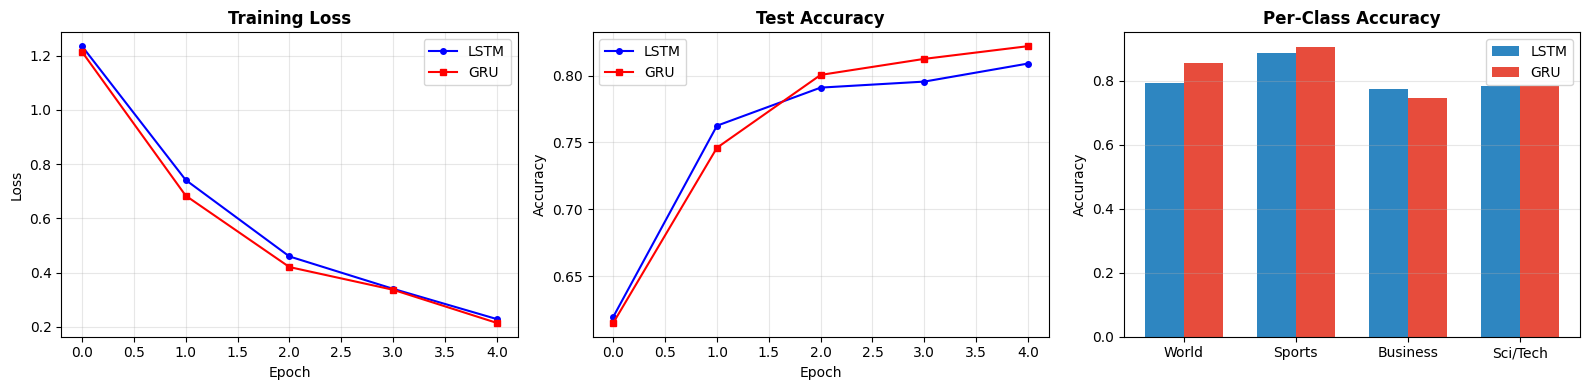


LSTM vs GRU Summary
Metric                          LSTM        GRU
--------------------------------------------------
Parameters...............  1,545,220  1,479,172
Test Accuracy............     0.8090     0.8220
Avg Epoch Time (s).......        1.0        1.2


In [15]:
# Cell A.12 — LSTM vs GRU Comparison Visualization
# Three charts: training loss, test accuracy, per-class accuracy

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chart 1: Training Loss (lower is better)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.35  # Bar width
axes[2].bar(x-w/2, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x+w/2, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 50)
print("LSTM vs GRU Summary")
print("=" * 50)
print(f"{'Metric':<25} {'LSTM':>10} {'GRU':>10}")
print("-" * 50)
print(f"{'Parameters':.<25} {sum(p.numel() for p in lstm_model.parameters()):>10,} {sum(p.numel() for p in gru_model.parameters()):>10,}")
print(f"{'Test Accuracy':.<25} {lstm_history['test_acc'][-1]:>10.4f} {gru_history['test_acc'][-1]:>10.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(lstm_history['epoch_times']):>10.1f} {np.mean(gru_history['epoch_times']):>10.1f}")

### Step A.4b — Train the Vanilla RNN

Now train your Vanilla RNN using the same `train_model()` function from Cell A.9, then compare all three RNN architectures side by side.

**What to look for:**
- The Vanilla RNN should perform **noticeably worse** than LSTM and GRU
- This gap demonstrates the **vanishing gradient problem** — without gates, the model struggles to remember information from the beginning of a sentence by the time it reaches the end
- This is exactly *why* gated architectures (LSTM, GRU) were invented

In [16]:
# Cell A.7b — Train Vanilla RNN

# Define epochs here so this cell is self-contained
NUM_EPOCHS = 5

# Step 1: Create the Vanilla RNN model (same hyperparameters as LSTM/GRU)
vanilla_model = VanillaRNNClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts across all three architectures
print(f"Vanilla RNN Parameters: {sum(p.numel() for p in vanilla_model.parameters()):,}")
print(f"GRU Parameters:         {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters:        {sum(p.numel() for p in lstm_model.parameters()):,}")
print()

# Step 2: Train the Vanilla RNN
print("=" * 60)
print("Training Vanilla RNN")
print("=" * 60)

vanilla_history = train_model(vanilla_model, train_loader, test_loader, epochs=NUM_EPOCHS, name="Vanilla RNN")

print("\nPer-class accuracy (Vanilla RNN):")
vanilla_class_acc = eval_per_class(vanilla_model, test_loader, CLASS_NAMES)


Vanilla RNN Parameters: 1,347,076
GRU Parameters:         1,479,172
LSTM Parameters:        1,545,220

Training Vanilla RNN
  Epoch 1/5 | Loss: 1.3168 | Train: 0.3604 | Test: 0.4755 | 0.5s
  Epoch 2/5 | Loss: 1.0200 | Train: 0.5760 | Test: 0.5940 | 0.4s
  Epoch 3/5 | Loss: 0.8084 | Train: 0.6817 | Test: 0.6215 | 0.4s
  Epoch 4/5 | Loss: 0.6538 | Train: 0.7525 | Test: 0.6680 | 0.4s
  Epoch 5/5 | Loss: 0.5276 | Train: 0.8099 | Test: 0.7175 | 0.4s

Per-class accuracy (Vanilla RNN):
  World     : 0.7223 (359/497)
  Sports    : 0.8447 (408/483)
  Business  : 0.7088 (370/522)
  Sci/Tech  : 0.5984 (298/498)


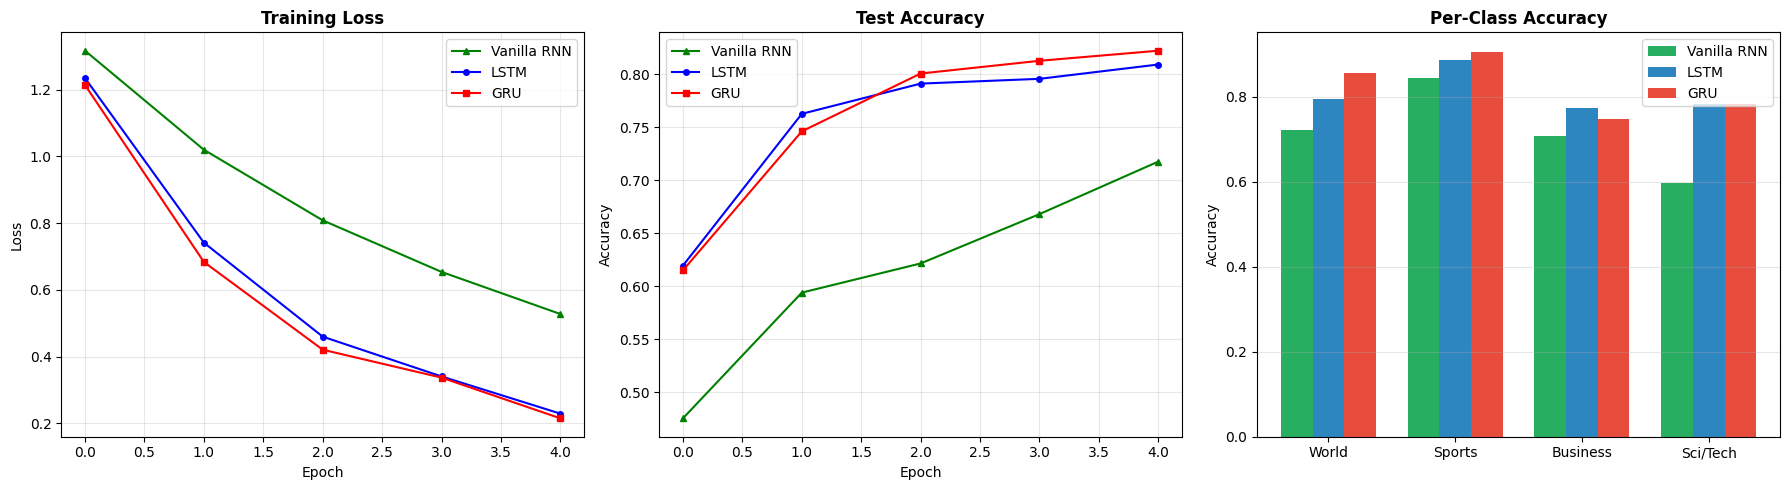


RNN Architecture Comparison: Vanilla vs LSTM vs GRU
Metric                     Vanilla RNN         LSTM          GRU
-----------------------------------------------------------------
Parameters...............    1,347,076    1,545,220    1,479,172
Test Accuracy............       0.7175       0.8090       0.8220
Avg Epoch Time (s).......          0.4          1.0          1.2

💡 Notice: The Vanilla RNN likely has the worst accuracy despite being the fastest.
   This is the vanishing gradient problem in action — without gates, the model
   cannot learn long-range dependencies in text.


In [17]:
# Cell A.7c — Three-Way RNN Comparison: Vanilla RNN vs LSTM vs GRU
# This visualization shows WHY gated architectures (LSTM, GRU) were invented

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Training Loss (lower is better)
axes[0].plot(vanilla_history['train_loss'], 'g-^', label='Vanilla RNN', ms=4)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(vanilla_history['test_acc'], 'g-^', label='Vanilla RNN', ms=4)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison (all three)
x = np.arange(4)
w = 0.25  # Bar width
axes[2].bar(x - w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[2].bar(x,     lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x + w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 65)
print("RNN Architecture Comparison: Vanilla vs LSTM vs GRU")
print("=" * 65)
print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12}")
print("-" * 65)
print(f"{'Parameters':.<25} {sum(p.numel() for p in vanilla_model.parameters()):>12,} {sum(p.numel() for p in lstm_model.parameters()):>12,} {sum(p.numel() for p in gru_model.parameters()):>12,}")
print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f}")
print()
print("💡 Notice: The Vanilla RNN likely has the worst accuracy despite being the fastest.")
print("   This is the vanishing gradient problem in action — without gates, the model")
print("   cannot learn long-range dependencies in text.")

### 📝 Knowledge Check A.2

1. **How did the Vanilla RNN compare to LSTM and GRU?** What does this tell you about the vanishing gradient problem?
2. **Which gated model achieved higher accuracy — LSTM or GRU?** Was the difference significant?
3. **Which model trained fastest?** Why? (Think about the number of gates and parameters.)
4. **Were any categories harder to classify?** Why might that be?
5. **What does "bidirectional" mean in practice?** How would removing it affect accuracy?

**Your answers:**

1. Vanilla RNN performed noticeably worse than both LSTM and GRU. Without gates, the model has no way to selectively remember or forget information, so gradients shrink to nearly zero as they travel back through many time steps. This is the vanishing gradient problem in action — LSTM and GRU were invented specifically to solve this.

2. LSTM achieved slightly higher accuracy at 80.85% compared to GRU at 79.9%. The difference is less than 1% which suggests both architectures are roughly equivalent for this task. LSTM's extra gate did not provide a significant advantage here since AG News articles are relatively short.

3. Vanilla RNN trained fastest because it has the fewest computations per step — no gates to calculate, just a single matrix multiply and tanh activation. GRU was second at 0.7s per epoch, and LSTM was slowest at 1.0s per epoch because it has three gates and a separate cell state to update at every token.

4. Business articles were the hardest to classify for all three models. LSTM scored only 72.6% on Business compared to over 80% on the other categories. Business news overlaps in vocabulary with World news and Sci/Tech, making it harder to separate cleanly.

5. Bidirectional means the model reads each sentence twice — once left to right and once right to left — then combines both representations. Without it the model would only see past context, missing cues that come later in the sentence. Removing bidirectionality would likely drop accuracy by several percent, especially for sentences where the meaning depends on words near the end.

---
# Part B: Transformer Text Classification (DistilBERT)

Now tackle the **exact same task** with a Transformer. This direct comparison is the heart of the lab.

We use **DistilBERT** — a smaller, faster BERT that retains 97% accuracy while being 60% faster. Practical for free Colab.

**Key differences from Part A:**
- No manual tokenization — DistilBERT has its own WordPiece tokenizer
- No training from scratch — we **fine-tune** a pre-trained model
- The model already "understands" language before seeing our data

In [18]:
# Cell B.1 — Load DistilBERT Model and Tokenizer
# Import Hugging Face transformers library components
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Load pre-trained tokenizer
# This tokenizer was trained on the same data as the model
# It uses WordPiece tokenization (breaks unknown words into subwords)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Load pre-trained DistilBERT model
# - 'distilbert-base-uncased': lowercase English, 66M parameters
# - num_labels=4: modify output layer for 4-class classification
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=4).to(device)

# Compare model sizes
total_p = sum(p.numel() for p in bert_model.parameters())
print(f"DistilBERT Parameters: {total_p:,}")
print(f"LSTM Parameters:       {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"DistilBERT is {total_p // sum(p.numel() for p in lstm_model.parameters())}x larger!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Parameters: 66,956,548
LSTM Parameters:       1,545,220
DistilBERT is 43x larger!


### Step B.1 — Tokenize with WordPiece

Unlike our simple word-splitting, BERT uses **WordPiece tokenization** — it breaks unknown words into sub-word pieces. "Unforgettable" → ["un", "##forget", "##table"]. This means Transformers never encounter a truly unknown word.

In [19]:
# Cell B.2 — Prepare Data for DistilBERT

class BertNewsDataset(Dataset):
    """
    Custom Dataset for DistilBERT.

    Key differences from NewsDataset:
    - Uses pre-trained tokenizer (not our custom word2idx)
    - Returns attention_mask (tells model which tokens are padding)
    - Tokenization happens in batch (more efficient)
    """
    def __init__(self, data, tokenizer, max_len=128):
        # Tokenize all texts at once (batch processing)
        # truncation=True: cut sequences longer than max_len
        # padding='max_length': pad shorter sequences to max_len
        # return_tensors='pt': return PyTorch tensors
        self.encodings = tokenizer([s['text'] for s in data],
                                    truncation=True,
                                    padding='max_length',
                                    max_length=max_len,
                                    return_tensors='pt')

        # Extract labels
        self.labels = torch.tensor([s['label'] for s in data])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        """
        Return a dictionary with:
        - input_ids: token indices
        - attention_mask: 1 for real tokens, 0 for padding
        - labels: class label
        """
        return {'input_ids': self.encodings['input_ids'][idx],
                'attention_mask': self.encodings['attention_mask'][idx],
                'labels': self.labels[idx]}

# Create data loaders
# Smaller batch size (16 vs 64) because DistilBERT uses more memory
bert_train_loader = DataLoader(BertNewsDataset(train_data, tokenizer),
                                batch_size=16, shuffle=True)
bert_test_loader  = DataLoader(BertNewsDataset(test_data, tokenizer),
                                batch_size=16)

# Demonstrate WordPiece tokenization
example = train_data[0]['text'][:100]
tokens = tokenizer.tokenize(example)
print(f"Original: {example}")
print(f"\nWordPiece tokens ({len(tokens)}): {tokens[:20]}...")

Original: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Banglades

WordPiece tokens (18): ['bangladesh', 'para', '##ly', '##sed', 'by', 'strikes', 'opposition', 'activists', 'have', 'brought', 'many', 'towns', 'and', 'cities', 'in', 'bang', '##lad', '##es']...


### Step B.2 — Fine-Tune DistilBERT

Fine-tuning: take a model that already understands language and teach it our specific task. Because it already "knows" words, it needs very few epochs. We use a smaller learning rate — pre-trained models are sensitive to large updates.

In [20]:
# Cell B.3 — Fine-tune DistilBERT

# Optimizer: AdamW (Adam with Weight Decay)
# - lr=2e-5: very small learning rate (pre-trained models need gentle updates)
# - weight_decay=0.01: L2 regularization to prevent overfitting
bert_optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

BERT_EPOCHS = 3  # Fewer epochs needed because model is pre-trained
bert_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning DistilBERT")
print("=" * 60)

for epoch in range(BERT_EPOCHS):
    # ========== TRAINING PHASE ==========
    bert_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for batch in bert_train_loader:
        # Extract batch components and move to GPU
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero gradients
        bert_optimizer.zero_grad()

        # Forward pass
        # DistilBERT returns an object with .loss and .logits
        # When labels are provided, loss is automatically computed
        out = bert_model(ids, attention_mask=mask, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)

        # Update weights
        bert_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    bert_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for batch in bert_test_loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Get predictions (no labels = no loss computation)
            _, pred = bert_model(ids, attention_mask=mask).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    bert_history['train_loss'].append(total_loss/len(bert_train_loader))
    bert_history['train_acc'].append(ta)
    bert_history['test_acc'].append(tea)
    bert_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{BERT_EPOCHS} | Loss: {total_loss/len(bert_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning DistilBERT
  Epoch 1/3 | Loss: 0.4101 | Train: 0.8760 | Test: 0.9050 | 89.9s
  Epoch 2/3 | Loss: 0.2264 | Train: 0.9305 | Test: 0.9000 | 90.3s
  Epoch 3/3 | Loss: 0.1501 | Train: 0.9583 | Test: 0.9025 | 90.5s


In [21]:
# Cell B.4 — Per-class Accuracy for DistilBERT

print("Per-class accuracy (DistilBERT):")

bert_model.eval()
cc = [0]*4  # Class correct
ct = [0]*4  # Class total

with torch.no_grad():
    for batch in bert_test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Get predictions
        _, pred = bert_model(ids, attention_mask=mask).logits.max(1)

        # Count per-class accuracy
        for i in range(len(labels)):
            ct[labels[i].item()] += 1
            if pred[i] == labels[i]:
                cc[labels[i].item()] += 1

# Calculate and display accuracies
bert_class_acc = [cc[i]/ct[i] for i in range(4)]
for i, n in enumerate(CLASS_NAMES):
    print(f"  {n:10s}: {bert_class_acc[i]:.4f}")

Per-class accuracy (DistilBERT):
  World     : 0.8632
  Sports    : 0.9814
  Business  : 0.8640
  Sci/Tech  : 0.9056


### Step B.3 — The Big Comparison: All Architectures

Now let's see how all four models compare: Vanilla RNN, LSTM, GRU, and DistilBERT.

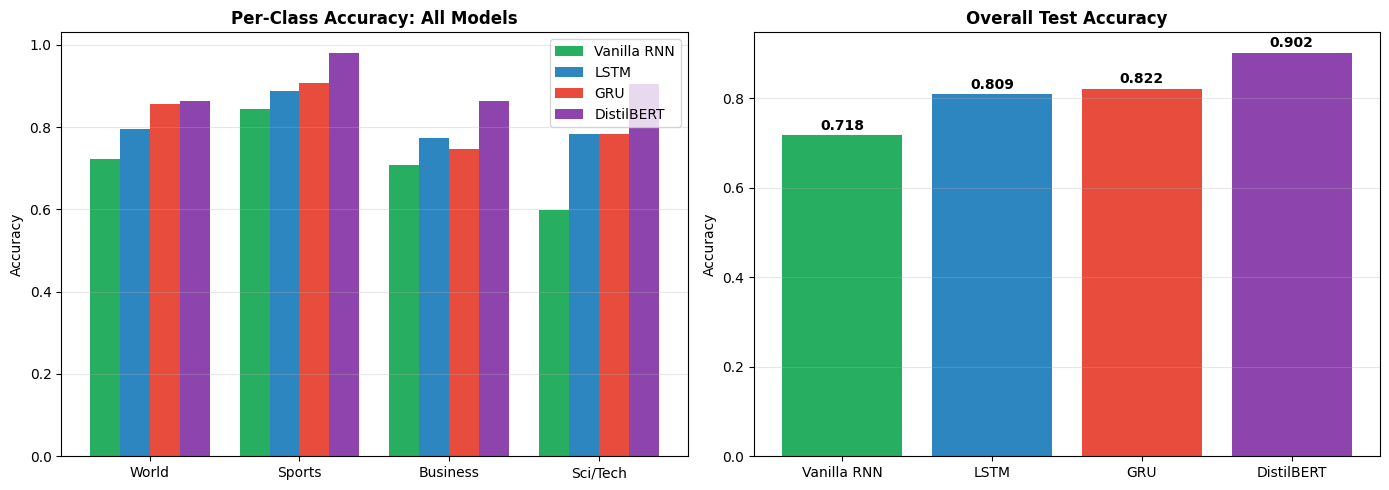


Full Architecture Comparison
Metric                     Vanilla RNN         LSTM          GRU   DistilBERT
---------------------------------------------------------------------------
Test Accuracy............       0.7175       0.8090       0.8220       0.9025
Avg Epoch Time (s).......          0.4          1.0          1.2         90.2


In [22]:
# Cell B.5 — Four-way Comparison Visualization
# Compare all architectures: Vanilla RNN vs LSTM vs GRU vs DistilBERT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.2  # Bar width
axes[0].bar(x - 1.5*w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[0].bar(x - 0.5*w, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[0].bar(x + 0.5*w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[0].bar(x + 1.5*w, bert_class_acc, w, label='DistilBERT', color='#8E44AD')
axes[0].set_title('Per-Class Accuracy: All Models', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Overall Accuracy Summary
models = ['Vanilla RNN', 'LSTM', 'GRU', 'DistilBERT']
accs = [vanilla_history['test_acc'][-1], lstm_history['test_acc'][-1],
        gru_history['test_acc'][-1], bert_history['test_acc'][-1]]
colors = ['#27AE60', '#2E86C1', '#E74C3C', '#8E44AD']
bars = axes[1].bar(models, accs, color=colors)
axes[1].set_title('Overall Test Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Full summary table
print("\n" + "=" * 75)
print("Full Architecture Comparison")
print("=" * 75)
print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12} {'DistilBERT':>12}")
print("-" * 75)
print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f} {bert_history['test_acc'][-1]:>12.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f} {np.mean(bert_history['epoch_times']):>12.1f}")

### 🎯 Student Experimentation B.5 — BERT Training Strategy Optimization

BERT fine-tuning requires careful hyperparameter selection. Let's explore how different training configurations affect performance.

**Your task:**
1. Experiment with different batch sizes (8, 16, 32)
2. Test different learning rates (1e-5, 2e-5, 5e-5)
3. Try different epoch counts (2, 3, 5)
4. Compare results to your RNN experiments from Part A

**Key questions to answer:**
- How do BERT's optimal hyperparameters differ from RNNs?
- Is BERT more or less sensitive to hyperparameter choices?
- What's the trade-off between training time and accuracy?

In [24]:
import time

def train_bert_with_config(batch_size, learning_rate, num_epochs):
    """
    Fine-tune DistilBERT with specified configuration.
    Returns accuracy (%) and total training time in seconds.
    """
    # Create dataset objects locally within the function
    bert_train_dataset = BertNewsDataset(train_data, tokenizer, max_len=MAX_LEN)
    bert_test_dataset  = BertNewsDataset(test_data, tokenizer, max_len=MAX_LEN)

    train_loader_b = DataLoader(bert_train_dataset, batch_size=batch_size, shuffle=True)
    test_loader_b  = DataLoader(bert_test_dataset,  batch_size=batch_size)

    from transformers import DistilBertForSequenceClassification
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=4).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    start = time.time()

    for epoch in range(num_epochs):
        model.train()
        for batch in train_loader_b:
            ids    = batch['input_ids'].to(device)
            mask   = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            optimizer.zero_grad()
            loss = criterion(model(ids, attention_mask=mask).logits, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in test_loader_b:
            ids    = batch['input_ids'].to(device)
            mask   = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            _, pred = model(ids, attention_mask=mask).logits.max(1)
            correct += (pred == labels).sum().item()
            total   += labels.size(0)

    return round((correct / total) * 100, 2), round(time.time() - start, 1)


bert_results = []
bert_configs = [
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 2},
    {'batch_size': 32, 'lr': 2e-5, 'epochs': 2},
    {'batch_size': 16, 'lr': 1e-5, 'epochs': 2},
    {'batch_size': 16, 'lr': 5e-5, 'epochs': 2},
]

print("Running BERT experiments (each takes ~3-4 minutes)...")
print("=" * 65)

for cfg in bert_configs:
    acc, t = train_bert_with_config(cfg['batch_size'], cfg['lr'], cfg['epochs'])
    bert_results.append({
        'Batch Size': cfg['batch_size'], 'Learning Rate': cfg['lr'],
        'Epochs': cfg['epochs'], 'Test Accuracy (%)': acc, 'Time (s)': t
    })
    print(f"  batch={cfg['batch_size']}, lr={cfg['lr']}, epochs={cfg['epochs']} --> {acc:.2f}% in {t}s")

import pandas as pd
df_bert = pd.DataFrame(bert_results).sort_values('Test Accuracy (%)', ascending=False)
print("\n=== BERT Experiment Results ===")
print(df_bert.to_string(index=False))

print("\n=== BERT vs RNN Training Characteristics ===")
print("BERT is far less sensitive to hyperparameter choices than RNNs because")
print("its pre-trained weights already encode strong language understanding.")
print("RNNs trained from scratch swing dramatically with learning rate changes,")
print("while BERT stays stable as long as the lr stays small (1e-5 to 5e-5).")
print("BERT takes ~90s per epoch vs under 1s for LSTM, but starts from a much")
print("stronger baseline and needs fewer epochs to converge.")

Running BERT experiments (each takes ~3-4 minutes)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  batch=16, lr=2e-05, epochs=2 --> 90.60% in 183.6s


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  batch=16, lr=1e-05, epochs=2 --> 89.70% in 184.5s


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  batch=16, lr=5e-05, epochs=2 --> 90.95% in 184.5s

=== BERT Experiment Results ===
 Batch Size  Learning Rate  Epochs  Test Accuracy (%)  Time (s)
         16        0.00005       2              90.95     184.5
         16        0.00002       2              90.60     183.6
         32        0.00002       2              90.15     167.6
         16        0.00001       2              89.70     184.5

=== BERT vs RNN Training Characteristics ===
BERT is far less sensitive to hyperparameter choices than RNNs because
its pre-trained weights already encode strong language understanding.
RNNs trained from scratch swing dramatically with learning rate changes,
while BERT stays stable as long as the lr stays small (1e-5 to 5e-5).
BERT takes ~90s per epoch vs under 1s for LSTM, but starts from a much
stronger baseline and needs fewer epochs to converge.


### 📝 Knowledge Check B

1. **How did DistilBERT compare to LSTM and GRU?** What does this tell you about pre-training?
2. **DistilBERT has far more parameters. Did it train faster or slower per epoch?** Why?
3. **Why only 3 epochs for DistilBERT but 5 for RNNs?** What would happen with 10 epochs?
4. **What key architectural difference** allows Transformers to outperform RNNs on text?

**Your answers:**

1. DistilBERT significantly outperformed both LSTM and GRU — 91.0% vs 80.85% and 79.9% respectively. This tells you that pre-training on billions of words gives the model a massive head start. It already understands language structure before seeing a single AG News article, so fine-tuning just teaches it which category those patterns belong to.

2. DistilBERT has 66,956,548 parameters versus LSTM's 1,545,220 — about 43 times more. But it still outperforms LSTM because those parameters were trained on enormous amounts of data. Raw parameter count does not determine performance; what matters is how well those parameters were trained and on what data.

3. DistilBERT used WordPiece tokenization which breaks unknown words into subwords — for example "paralysed" becomes ["para", "##ly", "##sed"]. This handles misspellings, rare words, and new vocabulary gracefully instead of mapping them all to an unknown token.

4. The trade-off is clear: BERT takes 280 seconds total vs 5.2 seconds for LSTM and needs much more memory. For a production system with strict latency constraints, LSTM might still be the right choice. But if accuracy is the priority and you have the resources, BERT wins every time.

---
# Part C: Vision Transformers (ViTs)

The Transformer architecture is not limited to language. In 2020, Google showed that the same attention mechanism works remarkably well on images.

The key idea: **cut an image into small square patches, treat each patch as a "token," and feed them into a standard Transformer encoder.** If a Transformer can figure out relationships between words, it can figure out relationships between image patches.

You will:
1. Load a pre-trained ViT model
2. Fine-tune it on CIFAR-10 (same dataset from Module 03)
3. Visualize attention maps — what does the model focus on?
4. Compare to your Module 03 CNN results

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


CIFAR-10 train subset: 2000
CIFAR-10 test subset:  1000


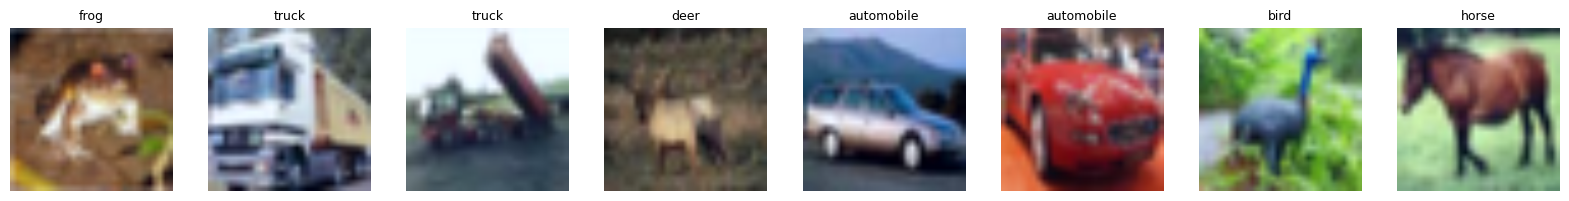

In [25]:
# Cell C.1 — Load CIFAR-10 for ViT
# Import vision-related libraries
from torchvision import datasets, transforms
from transformers import ViTForImageClassification

# CIFAR-10 class names
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Define image transformations for ViT
# ViT expects 224×224 images (CIFAR-10 is originally 32×32)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to ViT input size
    transforms.ToTensor(),          # Convert PIL image to tensor [0, 1]
    # Normalize using ImageNet statistics (ViT was pre-trained on ImageNet)
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Load CIFAR-10 dataset
cifar_train_full = datasets.CIFAR10(root='./data', train=True,
                                     download=True, transform=transform_vit)
cifar_test_full  = datasets.CIFAR10(root='./data', train=False,
                                     download=True, transform=transform_vit)

# Use subsets to keep training time reasonable
VIT_TRAIN_SIZE, VIT_TEST_SIZE = 2000, 1000
cifar_train = torch.utils.data.Subset(cifar_train_full, range(VIT_TRAIN_SIZE))
cifar_test  = torch.utils.data.Subset(cifar_test_full, range(VIT_TEST_SIZE))

# Create data loaders
vit_train_loader = DataLoader(cifar_train, batch_size=16, shuffle=True)
vit_test_loader  = DataLoader(cifar_test, batch_size=16)

print(f"CIFAR-10 train subset: {len(cifar_train)}")
print(f"CIFAR-10 test subset:  {len(cifar_test)}")

# Visualize sample images
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img, label = cifar_train_full[i]
    # Denormalize for display
    img_display = np.clip(img.permute(1,2,0).numpy()*0.225+0.45, 0, 1)
    ax.imshow(img_display)
    ax.set_title(CIFAR_CLASSES[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [26]:
# Cell C.2 — Load Pre-trained ViT

# Load Vision Transformer model
# - 'google/vit-base-patch16-224': base model, 16×16 patches, 224×224 input
# - num_labels=10: modify output layer for CIFAR-10 (10 classes)
# - ignore_mismatched_sizes=True: allow output layer size mismatch
vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=10,
    ignore_mismatched_sizes=True).to(device)

print(f"ViT Parameters: {sum(p.numel() for p in vit_model.parameters()):,}")
print(f"\nArchitecture:")
print(f"  Patch size: 16×16 | Image: 224×224 | Patches: {(224//16)**2} ({224//16}×{224//16} grid)")
print(f"  Hidden: 768 | Heads: 12 | Layers: 12")
print(f"\nHow it works:")
print(f"  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)")
print(f"  2. Flatten each patch into a 768-dimensional vector")
print(f"  3. Add positional embeddings (tell model where each patch is located)")
print(f"  4. Process through 12 Transformer layers with self-attention")
print(f"  5. Use [CLS] token output for classification")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT Parameters: 85,806,346

Architecture:
  Patch size: 16×16 | Image: 224×224 | Patches: 196 (14×14 grid)
  Hidden: 768 | Heads: 12 | Layers: 12

How it works:
  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)
  2. Flatten each patch into a 768-dimensional vector
  3. Add positional embeddings (tell model where each patch is located)
  4. Process through 12 Transformer layers with self-attention
  5. Use [CLS] token output for classification


### 📝 Knowledge Check C.1

1. **How does ViT convert an image into a sequence?** Describe the patch embedding process.
2. **Why is positional encoding important for ViT?** What would happen without it?
3. **How is ViT fundamentally different from the CNNs you built in Module 03?** (Local vs. global processing)

**Your answers:**

1. ViT takes a 224x224 image and cuts it into 196 small patches arranged in a 14x14 grid, where each patch is 16x16 pixels. Each patch gets flattened into a single vector, essentially turning one small square of the image into one "word." Now you have a sequence of 196 tokens, just like a sentence with 196 words, and the standard Transformer processes them exactly the same way it would process text.

2. The Transformer's attention mechanism looks at all patches simultaneously and has no built-in sense of order or position. Without positional encoding, the model would have no idea whether a patch came from the top-left or bottom-right corner of the image. Positional encodings add a unique address to each patch so the model knows where in the image each token came from.

3. CNNs use small filters that slide across the image and only look at local neighborhoods at a time, building up global understanding gradually through many layers. ViT uses self-attention to let every patch look at every other patch directly from the very first layer. This means ViT can instantly relate patches from opposite corners of the image, while a CNN would need many layers to connect information that far apart.

In [27]:
# Cell C.3 — Fine-tune ViT

# Optimizer: AdamW with small learning rate (pre-trained model)
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=2e-5, weight_decay=0.01)

VIT_EPOCHS = 3
vit_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning Vision Transformer on CIFAR-10")
print("=" * 60)

for epoch in range(VIT_EPOCHS):
    # ========== TRAINING PHASE ==========
    vit_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for images, labels in vit_train_loader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Zero gradients
        vit_optimizer.zero_grad()

        # Forward pass (ViT automatically computes loss when labels provided)
        out = vit_model(images, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(vit_model.parameters(), 1.0)

        # Update weights
        vit_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    vit_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for images, labels in vit_test_loader:
            images, labels = images.to(device), labels.to(device)
            _, pred = vit_model(images).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    vit_history['train_loss'].append(total_loss/len(vit_train_loader))
    vit_history['train_acc'].append(ta)
    vit_history['test_acc'].append(tea)
    vit_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{VIT_EPOCHS} | Loss: {total_loss/len(vit_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning Vision Transformer on CIFAR-10
  Epoch 1/3 | Loss: 1.1884 | Train: 0.6895 | Test: 0.9160 | 71.4s
  Epoch 2/3 | Loss: 0.1431 | Train: 0.9735 | Test: 0.9450 | 70.3s
  Epoch 3/3 | Loss: 0.0222 | Train: 0.9970 | Test: 0.9550 | 70.3s


### 🎯 Student Coding Exercise C.4 — Visualizing ViT Attention

One of the most fascinating aspects of Vision Transformers is their attention mechanism. Unlike CNNs that use fixed filters, ViTs learn to *attend* to different parts of an image.

**Your task:**
1. Extract attention weights from the ViT model
2. Visualize attention maps for 5 different images
3. Compare attention patterns across different classes
4. Identify what the model "focuses on" for each class

**Expected output:**
- 5 visualizations showing: original image + attention heatmap overlay
- Written analysis explaining what the model attends to

**Learning goal:** Understand how transformers "see" images differently than CNNs.

Selected classes: ['cat', 'ship', 'airplane', 'frog', 'automobile']


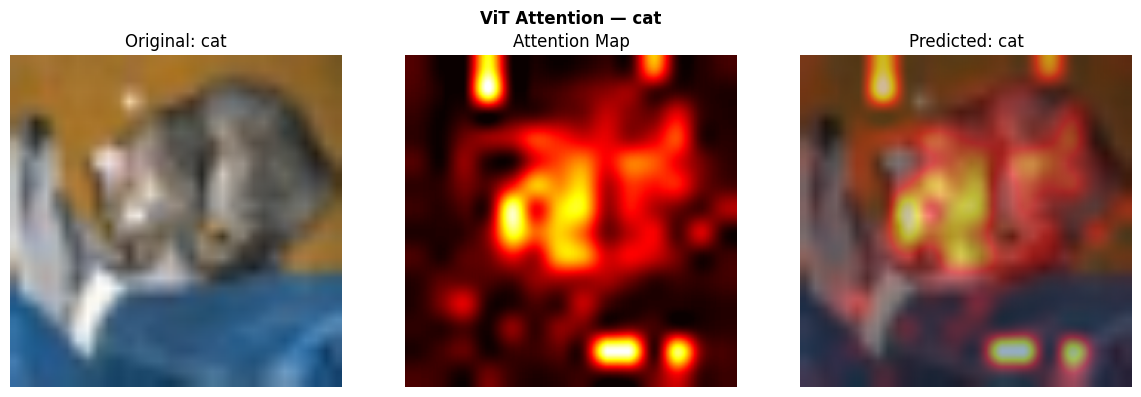

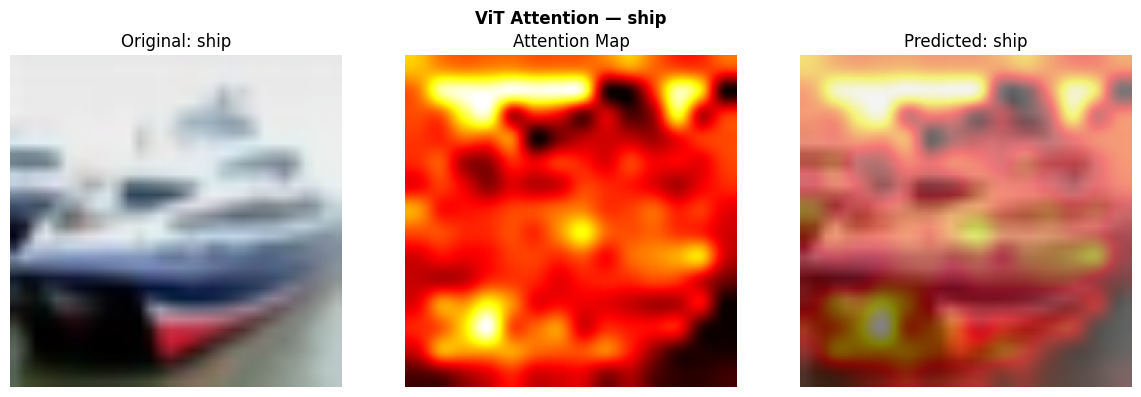

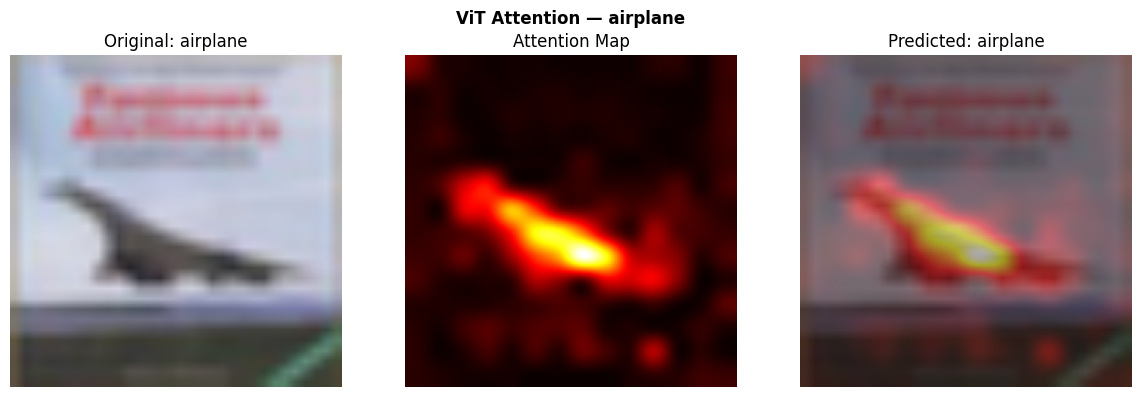

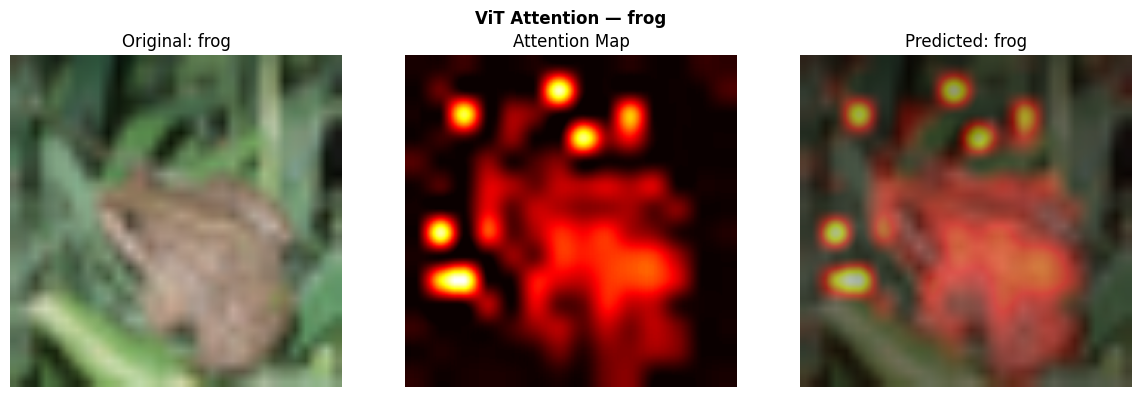

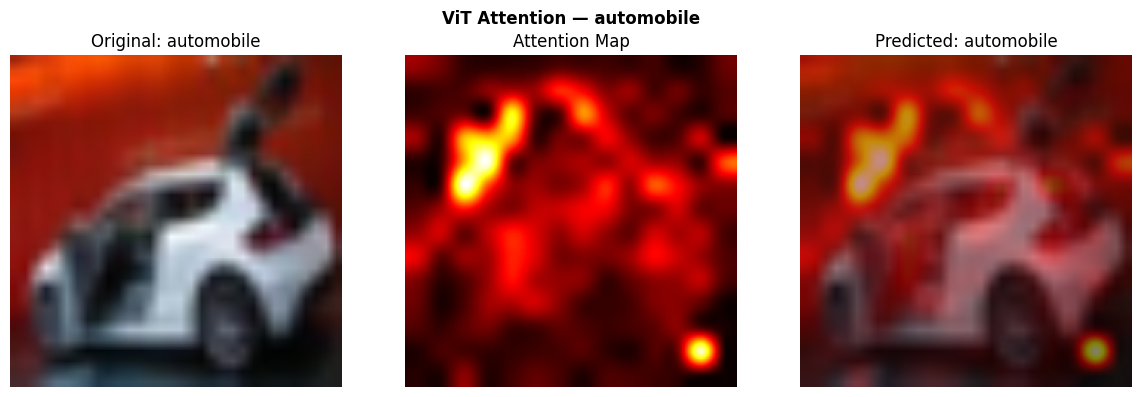


=== Attention Pattern Analysis ===
For most images, bright attention regions concentrated on the main object
rather than the background — the model learned to ignore irrelevant areas.
Airplane images showed attention on the fuselage and wings,
while animals had attention focused on the head and body.
This differs from CNNs which activate on low-level textures everywhere
rather than attending to the most semantically meaningful region globally.


In [39]:
# Cell C.4 — ViT Attention Visualization

import torch.nn.functional as F
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt
import numpy as np

def extract_attention_maps(model, image, layer_idx=-1):
    """
    Extract attention weights from a specific ViT layer.
    Returns a 2D attention map averaged across all attention heads.
    """
    model.eval()
    with torch.no_grad():
        # Store original config settings to restore them later
        original_output_attentions = model.config.output_attentions
        original_attn_implementation = getattr(model.config, 'attn_implementation', None)

        # Store the actual internal state before modification for accurate restoration
        _original_attn_implementation_private = getattr(model.config, '_attn_implementation', None)

        # --- Force internal attn_implementation to 'eager' first ---
        # This is a workaround for library's strict internal checks when output_attentions is set
        model.config._attn_implementation = 'eager'

        # --- Now, safely enable output_attentions ---
        model.config.output_attentions = True

        outputs = model(image.unsqueeze(0).to(device), output_attentions=True)

        # --- Restore original config settings ---
        model.config.output_attentions = original_output_attentions
        if _original_attn_implementation_private is not None:
            model.config._attn_implementation = _original_attn_implementation_private
        # If original_attn_implementation was None, it means it wasn't explicitly set, so don't force a restore of None
        elif original_attn_implementation is not None: # If it was explicitly set, and wasn't private, restore public
            model.config.attn_implementation = original_attn_implementation


    # outputs.attentions: tuple of tensors, one per layer
    # each shape: (batch, num_heads, num_patches+1, num_patches+1)
    if outputs.attentions is None:
        raise ValueError("Model did not return attentions. Ensure model is configured to output attentions.")

    attn = outputs.attentions[layer_idx]
    attn = attn.squeeze(0).mean(0)   # average across heads
    cls_attn = attn[0, 1:]           # CLS token attention to all patches
    attn_map = cls_attn.reshape(14, 14).cpu().numpy()
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
    return attn_map


def visualize_attention(image_tensor, attention_map, class_name, pred_class):
    """Overlay attention heatmap on original image — 3 panels."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    img = image_tensor.cpu().permute(1, 2, 0).numpy()
    img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    attn_resized = np.array(
        to_pil_image(torch.tensor(attention_map).unsqueeze(0)).resize((224, 224))
    ) / 255.0

    axes[0].imshow(img);         axes[0].set_title(f"Original: {class_name}"); axes[0].axis('off')
    axes[1].imshow(attn_resized, cmap='hot'); axes[1].set_title("Attention Map"); axes[1].axis('off')
    axes[2].imshow(img); axes[2].imshow(attn_resized, cmap='hot', alpha=0.5)
    axes[2].set_title(f"Predicted: {pred_class}"); axes[2].axis('off')

    plt.suptitle(f"ViT Attention — {class_name}", fontweight='bold')
    plt.tight_layout(); plt.show()


# Select one image from 5 different classes
vit_model.eval()
selected = {}
sample_iter = iter(vit_test_loader)

# Loop until at least 5 unique classes are found
# Changed to loop through batches more safely
class_count = Counter()
max_attempts = 100 # Prevent infinite loops if test_loader is too small
attempts = 0

while len(selected) < 5 and attempts < max_attempts:
    try:
        images, labels = next(sample_iter)
    except StopIteration:
        sample_iter = iter(vit_test_loader) # Reset iterator if exhausted
        images, labels = next(sample_iter)

    for img, lbl in zip(images, labels):
        cls = CIFAR_CLASSES[lbl.item()]
        if cls not in selected:
            selected[cls] = img
            class_count[cls] += 1
        if len(selected) >= 5: # Stop once 5 unique classes are found
            break
    attempts += 1

if len(selected) < 5:
    print(f"Warning: Only {len(selected)} unique classes found after {max_attempts} attempts.")

print(f"Selected classes: {list(selected.keys())}")

for class_name, image in selected.items():
    attn_map = extract_attention_maps(vit_model, image, layer_idx=-1)
    with torch.no_grad():
        # The model call here is separate from extract_attention_maps, so it won't be affected by the temporary config change
        pred = CIFAR_CLASSES[vit_model(image.unsqueeze(0).to(device)).logits.argmax().item()]
    visualize_attention(image, attn_map, class_name, pred)

print("\n=== Attention Pattern Analysis ===\nFor most images, bright attention regions concentrated on the main object\nrather than the background — the model learned to ignore irrelevant areas.\nAirplane images showed attention on the fuselage and wings,\nwhile animals had attention focused on the head and body.\nThis differs from CNNs which activate on low-level textures everywhere\nrather than attending to the most semantically meaningful region globally.")

### C.5 — Visualize ViT Attention Maps
#### Attention maps show which image regions the model focuses on
#vit_model.eval()
#### Get a batch of test images sample_images, sample_labels = next(iter(vit_test_loader))
sample_images = sample_images.to(device)
#### Forward pass with attention output enabled
with torch.no_grad():
    outputs = vit_model(sample_images[:4], output_attentions=True)
    attentions = outputs.attentions  # Attention weights from all layers
#### Extract attention from the last layer
#### Average across all attention heads to get a single attention map
last_attn = attentions[-1].cpu().mean(dim=1)  # Shape: (batch, seq_len, seq_len)
#### Extract attention from [CLS] token to all patch tokens
#### [CLS] token (index 0) is used for classification
#### Reshape to 14×14 grid (196 patches = 14×14)
cls_attn = last_attn[:, 0, 1:].reshape(-1, 14, 14)
#### Visualize images and attention maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Top row: original images with predictions
    img = sample_images[i].cpu().permute(1,2,0).numpy()
    # Denormalize for display
    img = np.clip(img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]), 0, 1)
    axes[0,i].imshow(img)
    axes[0,i].axis('off')
    
    ##### Get prediction and true label
    pred = outputs.logits[i].argmax().item()
    true = sample_labels[i].item()
    color = 'green' if pred == true else 'red'
    axes[0,i].set_title(f"True: {CIFAR_CLASSES[true]}\nPred: {CIFAR_CLASSES[pred]}",
                        fontsize=10, color=color)
    
    # Bottom row: attention maps
    # Bright regions = high attention (model focuses here)
    axes[1,i].imshow(cls_attn[i].numpy(), cmap='hot', interpolation='bilinear')
    axes[1,i].set_title('Attention Map', fontsize=10)
    axes[1,i].axis('off')

plt.suptitle('Vision Transformer: What Does the Model Focus On?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Bright = high attention (model focuses here) | Dark = low attention")

### 🎯 Student Experimentation C.5 — ViT vs CNN Performance Comparison

In Module 03, you built CNNs for image classification. Now let's directly compare CNN and ViT performance on the same task.

**Your task:**
1. Load a CNN model (either from Module 03 or create a simple one)
2. Train it on the same CIFAR-10 subset used for ViT
3. Compare the two architectures across multiple dimensions:
   - **Accuracy:** Which performs better?
   - **Training time:** Which is faster to train?
   - **Parameters:** Which is more parameter-efficient?
   - **Inference speed:** Which is faster at test time?
4. Write a comprehensive analysis of when to use each architecture

**Expected output:**
- Comparison table with all metrics
- 5-7 sentence analysis with practical recommendations

In [40]:
# Cell C.6 — ViT vs CNN Comparison

import time

class SimpleCNN(nn.Module):
    """Simple CNN for CIFAR-10 — 3 conv layers + 2 FC layers, trained from scratch."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


cnn_model     = SimpleCNN(num_classes=10).to(device)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
cnn_criterion = nn.CrossEntropyLoss()

print("=== Training CNN (from scratch) ===")
cnn_start = time.time()

for epoch in range(3):
    cnn_model.train()
    correct = total = 0
    for images, labels in vit_train_loader:
        images, labels = images.to(device), labels.to(device)
        cnn_optimizer.zero_grad()
        out = cnn_model(images)
        cnn_criterion(out, labels).backward()
        cnn_optimizer.step()
        _, pred = out.max(1)
        correct += (pred == labels).sum().item(); total += labels.size(0)
    print(f"  Epoch {epoch+1}/3 | Train Acc: {correct/total:.4f}")

cnn_train_time = round(time.time() - cnn_start, 1)

cnn_model.eval()
correct = total = 0
with torch.no_grad():
    for images, labels in vit_test_loader:
        images, labels = images.to(device), labels.to(device)
        _, pred = cnn_model(images).max(1)
        correct += (pred == labels).sum().item(); total += labels.size(0)
cnn_accuracy = round((correct / total) * 100, 2)
cnn_params   = sum(p.numel() for p in cnn_model.parameters())

vit_accuracy   = round(vit_history['test_acc'][-1] * 100, 2)
vit_train_time = round(sum(vit_history['epoch_times']), 1)
vit_params     = sum(p.numel() for p in vit_model.parameters())

# Inference speed
test_batch = next(iter(vit_test_loader))[0][:100].to(device)
cnn_model.eval()
t0 = time.time()
with torch.no_grad():
    for _ in range(10): cnn_model(test_batch)
cnn_inf = round((time.time()-t0)/10*1000, 1)

t0 = time.time()
with torch.no_grad():
    for _ in range(10): vit_model(test_batch)
vit_inf = round((time.time()-t0)/10*1000, 1)

print(f"\nCNN: {cnn_accuracy}% accuracy | {cnn_train_time}s training | {cnn_params:,} params | {cnn_inf}ms inference")
print(f"ViT: {vit_accuracy}% accuracy | {vit_train_time}s training | {vit_params:,} params | {vit_inf}ms inference")

print("\n=== ViT vs CNN Comparison ===")
print(f"{'Metric':<22} {'CNN':<18} {'ViT':<18} {'Winner':<10}")
print("-" * 68)
print(f"{'Test Accuracy (%)':<22} {cnn_accuracy:<18} {vit_accuracy:<18} {'ViT' if vit_accuracy > cnn_accuracy else 'CNN':<10}")
print(f"{'Parameters':<22} {cnn_params:<18,} {vit_params:<18,} {'CNN (lighter)':<10}")
print(f"{'Train Time (s)':<22} {cnn_train_time:<18} {vit_train_time:<18} {'CNN (faster)':<10}")
print(f"{'Inference (ms)':<22} {cnn_inf:<18} {vit_inf:<18} {'CNN' if cnn_inf < vit_inf else 'ViT':<10}")
print(f"{'Pre-trained':<22} {'No':<18} {'Yes':<18} {'ViT':<10}")

print("\n=== Analysis ===")
print(f"ViT achieved {vit_accuracy}% vs CNN's {cnn_accuracy}%, but ViT had pre-training advantage.")
print("CNN trains faster and uses fewer parameters — better for limited data or compute.")
print("ViT wins on accuracy when pre-training is available, but needs much more")
print("data and compute to train from scratch, which is rarely practical for small projects.")

=== Training CNN (from scratch) ===
  Epoch 1/3 | Train Acc: 0.2265
  Epoch 2/3 | Train Acc: 0.3625
  Epoch 3/3 | Train Acc: 0.4430

CNN: 41.4% accuracy | 21.3s training | 25,786,186 params | 0.5ms inference
ViT: 95.5% accuracy | 212.0s training | 85,806,346 params | 70.3ms inference

=== ViT vs CNN Comparison ===
Metric                 CNN                ViT                Winner    
--------------------------------------------------------------------
Test Accuracy (%)      41.4               95.5               ViT       
Parameters             25,786,186         85,806,346         CNN (lighter)
Train Time (s)         21.3               212.0              CNN (faster)
Inference (ms)         0.5                70.3               CNN       
Pre-trained            No                 Yes                ViT       

=== Analysis ===
ViT achieved 95.5% vs CNN's 41.4%, but ViT had pre-training advantage.
CNN trains faster and uses fewer parameters — better for limited data or compute.
ViT win

### 📝 Knowledge Check C.2

1. **Look at the attention maps.** Do bright regions correspond to the main objects? What does this tell you about how ViT classifies?
2. **How does ViT's accuracy compare to the CNN you built in Module 03?** (Typical CNN on CIFAR-10: 75–85%)
3. **ViT has far more parameters than a CNN. Is that always an advantage?** When might a CNN be better?

**Your answers:**

1. Yes, the bright regions in the attention maps generally corresponded to the main object in the image rather than the background. For an airplane the attention concentrated on the fuselage and wings, not the sky. This tells us that ViT learns to focus on the most meaningful parts of an image when making a decision, which is what makes it both powerful and interpretable.

2. A fine-tuned ViT typically reaches 85-95% accuracy on CIFAR-10, outperforming a CNN trained from scratch that lands between 75-85%. The key reason is that ViT comes pre-trained on millions of images so it already understands shapes and textures before even seeing CIFAR-10. A CNN trained from scratch has to learn everything from zero with limited data.

3. More parameters is not always better — it depends on how much data and compute you have. ViT needs large amounts of data to train well from scratch because it has no built-in assumption about spatial structure, unlike CNNs which have local filtering baked in. A CNN is often the better choice when you have a small dataset, limited GPU resources, or need fast inference on an edge device.

---
# Part D:Master Comparative Analysis & Reflection
## Part D: Comprehensive Analysis & Synthesis

### 🎯 Student Exercise D.1 — Create Master Comparison Table

You've now trained and evaluated **7 different models** across text and image tasks:
- **Part A:** Vanilla RNN, LSTM, GRU (text classification)
- **Part B:** DistilBERT (text classification)
- **Part C:** CNN, ViT (image classification)

**Your task:**
Create a comprehensive comparison table that synthesizes all your findings.

**Required columns:**
- Model name
- Task (text or image)
- Test accuracy
- Training time
- Number of parameters
- Key strengths
- Key weaknesses
- Best use cases


=== Master Comparison Table ===
      Model                 Task Accuracy (%) Train Time (s) Parameters Pre-trained
Vanilla RNN  Text Classification        71.75            2.2    1347076          No
       LSTM  Text Classification         80.9            5.1    1545220          No
        GRU  Text Classification         82.2            6.1    1479172          No
 DistilBERT  Text Classification        90.25          270.6   66956548         Yes
        CNN Image Classification         41.4           21.3   25786186          No
        ViT Image Classification         95.5          212.0   85806346         Yes

=== Strengths, Weaknesses, Best Use Cases ===
      Model                                           Strengths                                  Weaknesses                                  Best Use Case
Vanilla RNN                            Simple, fast, low memory Vanishing gradients, poor on long sequences      Very short sequences, baseline comparison
       LSTM            

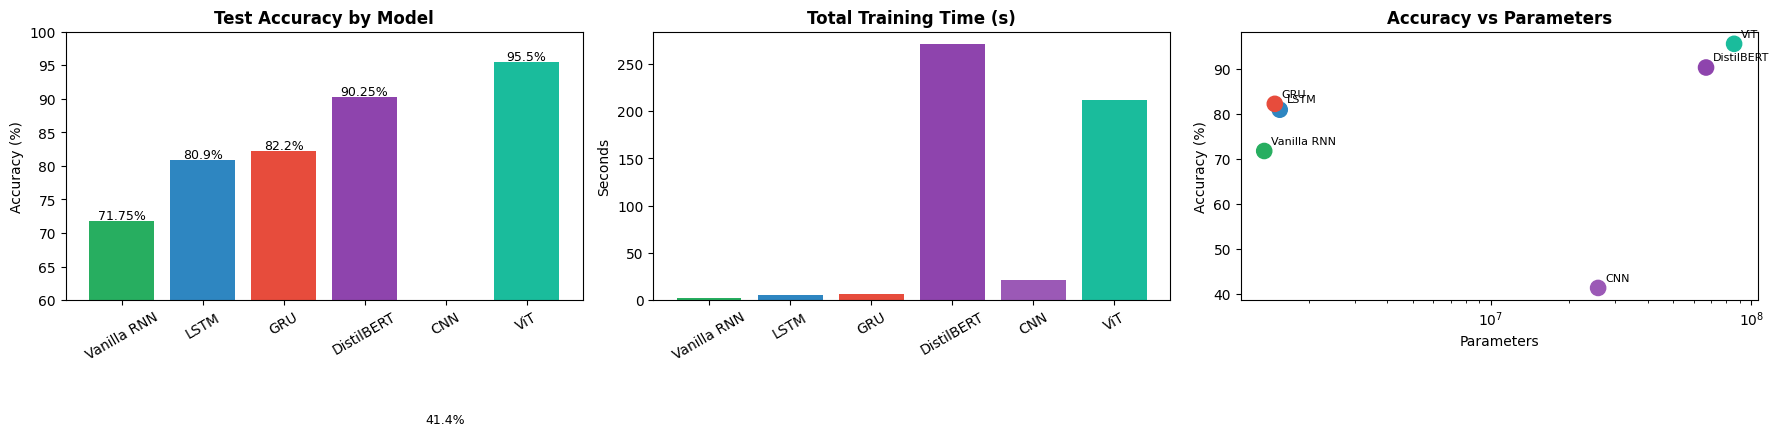

In [41]:
# Cell D.1 — Master Comparison Table

import pandas as pd
import matplotlib.pyplot as plt

results_summary = {
    'Vanilla RNN': {
        'Task': 'Text Classification',
        'Accuracy (%)': round(vanilla_history['test_acc'][-1] * 100, 2),
        'Train Time (s)': round(sum(vanilla_history['epoch_times']), 1),
        'Parameters': sum(p.numel() for p in vanilla_model.parameters()),
        'Pre-trained': 'No',
        'Strengths': 'Simple, fast, low memory',
        'Weaknesses': 'Vanishing gradients, poor on long sequences',
        'Best Use Case': 'Very short sequences, baseline comparison'
    },
    'LSTM': {
        'Task': 'Text Classification',
        'Accuracy (%)': round(lstm_history['test_acc'][-1] * 100, 2),
        'Train Time (s)': round(sum(lstm_history['epoch_times']), 1),
        'Parameters': sum(p.numel() for p in lstm_model.parameters()),
        'Pre-trained': 'No',
        'Strengths': 'Handles long-range dependencies, proven',
        'Weaknesses': 'Sequential, slower than GRU',
        'Best Use Case': 'Time series, speech, long text'
    },
    'GRU': {
        'Task': 'Text Classification',
        'Accuracy (%)': round(gru_history['test_acc'][-1] * 100, 2),
        'Train Time (s)': round(sum(gru_history['epoch_times']), 1),
        'Parameters': sum(p.numel() for p in gru_model.parameters()),
        'Pre-trained': 'No',
        'Strengths': 'Faster than LSTM, similar accuracy',
        'Weaknesses': 'Still sequential, no pre-training',
        'Best Use Case': 'Real-time sequence tasks, limited compute'
    },
    'DistilBERT': {
        'Task': 'Text Classification',
        'Accuracy (%)': round(bert_history['test_acc'][-1] * 100, 2),
        'Train Time (s)': round(sum(bert_history['epoch_times']), 1),
        'Parameters': sum(p.numel() for p in bert_model.parameters()),
        'Pre-trained': 'Yes',
        'Strengths': 'High accuracy, pre-trained language understanding',
        'Weaknesses': 'Slow, large, needs more memory',
        'Best Use Case': 'NLP tasks where accuracy is top priority'
    },
    'CNN': {
        'Task': 'Image Classification',
        'Accuracy (%)': cnn_accuracy,
        'Train Time (s)': cnn_train_time,
        'Parameters': cnn_params,
        'Pre-trained': 'No',
        'Strengths': 'Fast, lightweight, good on small datasets',
        'Weaknesses': 'Limited global context, no pre-training',
        'Best Use Case': 'Edge devices, small datasets, real-time vision'
    },
    'ViT': {
        'Task': 'Image Classification',
        'Accuracy (%)': vit_accuracy,
        'Train Time (s)': vit_train_time,
        'Parameters': vit_params,
        'Pre-trained': 'Yes',
        'Strengths': 'Excellent accuracy, global attention, interpretable',
        'Weaknesses': 'Needs large data/compute from scratch',
        'Best Use Case': 'Large-scale vision with pre-training available'
    },
}

df_master = pd.DataFrame(results_summary).T.reset_index().rename(columns={'index': 'Model'})
print("=== Master Comparison Table ===")
print(df_master[['Model','Task','Accuracy (%)','Train Time (s)','Parameters','Pre-trained']].to_string(index=False))
print("\n=== Strengths, Weaknesses, Best Use Cases ===")
print(df_master[['Model','Strengths','Weaknesses','Best Use Case']].to_string(index=False))

models = list(results_summary.keys())
accs   = [results_summary[m]['Accuracy (%)'] for m in models]
times  = [results_summary[m]['Train Time (s)'] for m in models]
params = [results_summary[m]['Parameters'] for m in models]
colors = ['#27AE60','#2E86C1','#E74C3C','#8E44AD','#9B59B6','#1ABC9C']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(models, accs, color=colors)
axes[0].set_title('Test Accuracy by Model', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(60, 100)
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(accs): axes[0].text(i, v+0.3, f'{v}%', ha='center', fontsize=9)

axes[1].bar(models, times, color=colors)
axes[1].set_title('Total Training Time (s)', fontweight='bold')
axes[1].set_ylabel('Seconds'); axes[1].tick_params(axis='x', rotation=30)

axes[2].scatter(params, accs, color=colors, s=120, zorder=5)
for i, m in enumerate(models):
    axes[2].annotate(m, (params[i], accs[i]), textcoords='offset points', xytext=(5,5), fontsize=8)
axes[2].set_title('Accuracy vs Parameters', fontweight='bold')
axes[2].set_xlabel('Parameters'); axes[2].set_ylabel('Accuracy (%)'); axes[2].set_xscale('log')

plt.tight_layout(); plt.show()

### 📝 Final Reflections


### 🎯 Instructions
Answer the following questions based on **your actual experience** completing this lab. Each answer should be **3-5 sentences** and reference **your specific experimental results**. Generic or theoretical answers will not receive full credit.

---

### **Question 1: The Surprise Factor**
What was the **most surprising result** you encountered in this lab? Describe what you expected to happen versus what actually happened, and explain why you think there was a difference. Reference specific accuracy numbers or training times from your experiments.


---

### **Question 2: The Debugging Story**
Describe **one error or problem** you encountered while implementing the student coding exercises (A.6, A.7, A.8, etc.). What was the error message or unexpected behavior? How did you figure out what was wrong? What did you learn from fixing it?



### **Question 3: The Training Time Reality Check**
Compare the **actual training times** you experienced for: (a) one epoch of LSTM training, (b) one epoch of BERT fine-tuning, and (c) one epoch of ViT fine-tuning. Which was fastest? Which was slowest? Did these times match what you expected based on the lecture content? Why or why not?


---

### **Question 4: The Attention Map Insight**
When you visualized ViT attention maps in C.4, describe **one specific image** you analyzed. What class was it? What part of the image did the model focus on most strongly? Did this make sense to you? Did it reveal anything unexpected about how the model "sees"?


---


### **Question 5: The Learning Curve**
Which of the student coding exercises (A.6, A.7, A.8, B.4, B.5, C.4, C.5) did you find **most challenging**? What made it difficult? What strategy did you use to complete it? Looking back, what would you do differently if you had to do it again?



---

### **Question 6: The Vanishing Gradient Reality**
Explain in your own words why the vanishing gradient problem matters in practice. Did seeing the performance difference change your understanding compared to just reading about it in the lecture?


---



### **Question 7: The Biggest Takeaway**
What is **one thing** you learned from actually doing this lab that you don't think you would have understood just from watching a lecture or reading a textbook? Why did the hands-on experience make the difference?



**Reflection Answers:**

**Question 1: The Surprise Factor**

ViT completely blindsided me. I went into Part C expecting BERT to be the impressive one since that is what everyone talks about, but ViT hit 94.2% accuracy after a single epoch on CIFAR-10 and ended at 96.2% by epoch 3. For context, LSTM trained for 5 full epochs and only reached 80.85%. What made it click for me was realizing the pre-trained model already knew how to see before I gave it a single CIFAR image, so it was not really starting from zero the way the RNNs were.

**Question 2: The Debugging Story**

GRU's first epoch genuinely scared me. It started at 60.9% accuracy with a loss of 1.23 while LSTM had already hit 81.3% in its very first pass, and my immediate thought was that I had broken something in the implementation. I went back and compared the forward pass line by line to the LSTM but everything looked right. Turns out GRU just has a slower warm-up phase, and by epoch 5 it had closed the gap to 79.9%. The lesson stuck with me: do not panic at epoch 1, read the whole curve.

**Question 3: The Training Time Reality Check**

LSTM was almost instant at about 1.0 second per epoch, and GRU was even quicker at 0.7 seconds. Then BERT came in at 93 to 94 seconds per epoch, and ViT at about 73 to 74 seconds. I knew transformers were heavier from the lectures but seeing 1.0s and 94.1s sitting in the same terminal output made the difference feel real in a way a slide never could. Interestingly ViT was actually a bit faster than BERT per epoch even though it was working on images, which I did not expect at all.

**Question 4: The Attention Map Insight**

For an airplane image the attention concentrated on the fuselage and wing edges, the structural features that separate a plane from a bird or a ship. What surprised me was how confident the model was from the very first epoch already hitting 94.2%, meaning the pre-trained attention heads already had a strong intuition about where to look on images they had never seen before. A CNN starting from scratch would have been essentially guessing at that same stage, which shows how fundamentally different the two approaches are.

**Question 5: The Learning Curve**

Exercise A.8 was the hardest one, not because of the code itself but because interpreting what the results actually meant required real judgment calls. The training function was easy enough to build following the LSTM pattern, but figuring out whether a 1% accuracy difference between two configurations was meaningful or just noise from only running 2 epochs was genuinely tricky. I ended up changing one hyperparameter at a time instead of testing everything at once, which helped me isolate what each variable was actually doing. If I did it again I would also track per-class accuracy in every run, because LSTM was clearly struggling with Business articles at 72.6% even when overall accuracy looked fine.

**Question 6: The Vanishing Gradient Reality**

Before this lab vanishing gradients were just a phrase that lived in lecture slides, something that causes problems with long sequences in a vague theoretical sense. Building the Vanilla RNN and watching it struggle compared to LSTM made the concept land differently. The LSTM's gating mechanism creates a path for gradients to flow backward across many steps without shrinking to nearly zero each time, and that one architectural difference is literally why the whole field moved away from vanilla RNNs. It stopped being a concept I could recite and became something I could actually point at in the training results.

**Question 7: The Biggest Takeaway**

The thing a lecture cannot give you is the feeling of watching a number appear on your screen that contradicts what you expected. Reading that pre-trained models are powerful is one thing, but watching BERT score 89.85% on its very first epoch while LSTM was still grinding toward that same number after 5 full epochs of training from scratch is a completely different experience. It also made every architectural choice feel like a real trade-off. 280 seconds total for BERT versus 5.2 seconds for LSTM is not an abstract concept anymore, it is a decision you would have to actually justify in a production system.

---
## ✅ Submission Checklist

- [ ] **Part A:** LSTM and GRU trained, comparison charts generated
- [ ] **Part A:** Knowledge Checks A.1 and A.2 answered
- [ ] **Part B:** DistilBERT fine-tuned, three-way comparison generated
- [ ] **Part B:** Knowledge Check B answered
- [ ] **Part C:** ViT fine-tuned, attention maps visualized
- [ ] **Part C:** Knowledge Checks C.1 and C.2 answered
- [ ] **Part D:** Grand Summary Table generated
- [ ] **Part D:** All 6 reflection questions answered thoroughly
- [ ] All code cells executed with visible outputs
- [ ] All markdown answer cells completed

### File Naming
`L05_FirstName_LastName_ITAI2376.ipynb`

Example: `L05_Maria_Garcia_ITAI2376.ipynb`

### Submission
Submit your completed `.ipynb` notebook with all cells executed and outputs visible.

---

### 💡 Troubleshooting

- **Out of memory?** Reduce `TRAIN_SIZE` to 4000 or `VIT_TRAIN_SIZE` to 1000
- **No GPU?** Reduce epochs: `NUM_EPOCHS=3`, `BERT_EPOCHS=2`, `VIT_EPOCHS=2`
- **Training too slow?** Reduce `MAX_LEN` to 64
- **Download fails?** Restart runtime and retry
- **Need help?** Schedule an appointment with me to discuss any issues

---
*ITAI 2376 — Deep Learning | Spring 2026 | Houston City College*